<a href="https://colab.research.google.com/github/notoctane/project/blob/main/colab/types_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Типы графов**

## 1. **Зачем нужна классификация графов**

Одну и ту же группу людей или объектов можно представить разными графами — всё зависит от того, какое отношение мы хотим показать.

- Если важно, **кто с кем знаком**, строим граф, где вершины — люди, а рёбра — факт знакомства.

- Если нужно увидеть **денежные переводы**, строим ориентированный граф, в котором каждое ребро показывает, кто кому перевёл деньги.

Чтобы правильно выбрать модель для задачи, надо понимать, какие бывают графы по структуре, направленности и связности. В этом параграфе мы разберём основные классификации, а также познакомимся с леммой о рукопожатиях и двудольными графами.


## **2. Классификация №1: по кратным рёбрам и петлям**



- **Обыкновенный граф** — самый строгий: **между любыми двумя вершинами не больше одного ребра, петли запрещены**. Подходит для моделирования единственного отношения (например, дороги между городами).  
- **Мультиграф** — разрешает несколько рёбер между одними и теми же вершинами (кратные рёбра), а также петли. Используется, когда между элементами есть несколько видов связей: автобусные, железнодорожные и авиамаршруты между городами или несколько каналов связи между серверами.  
- **Граф с петлями** — **допускает петли (рёбра, соединяющие вершину саму с собой)**. Удобен для отражения самодействий, например повторных покупок одного товара.  
- **Пустой граф** — **состоит только из изолированных вершин, рёбер нет вообще**. Важен в теории как крайний случай и отправная точка для построения сложных структур.


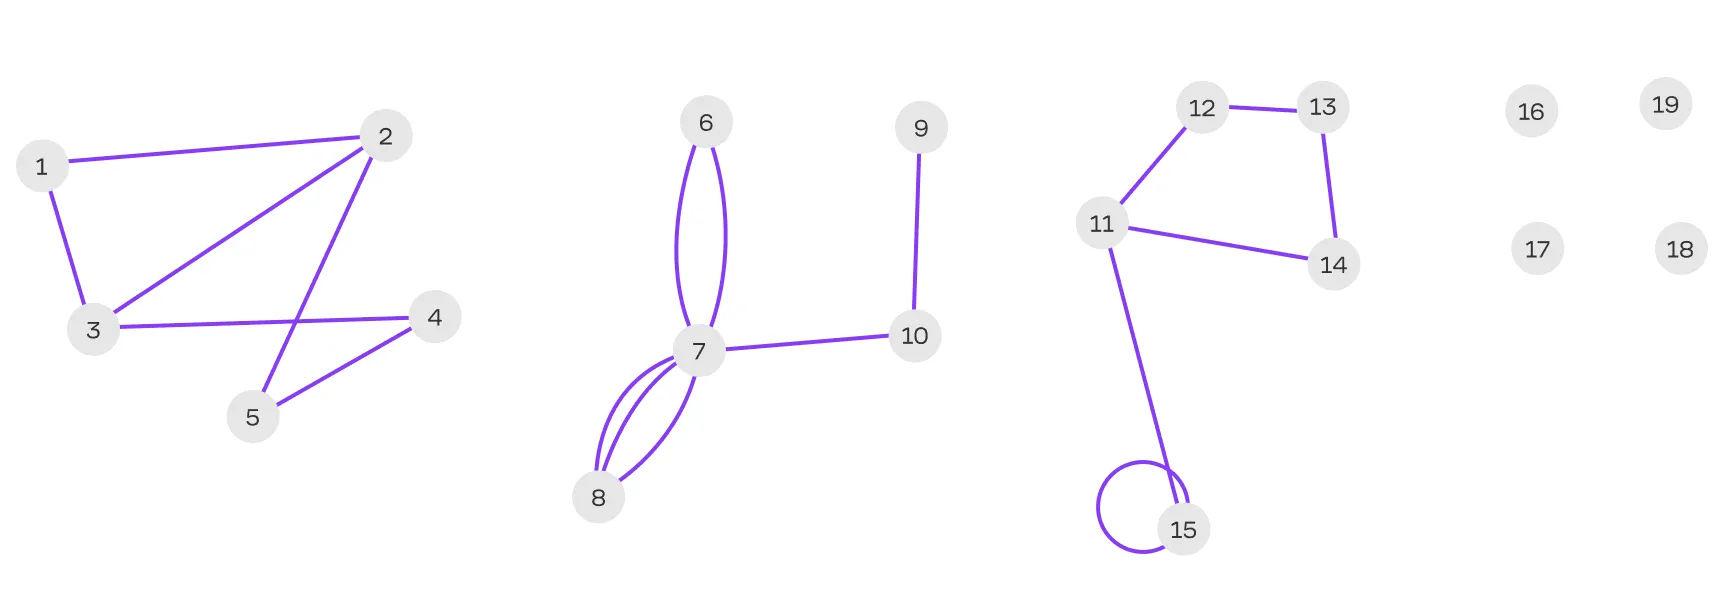

## **3. Классификация №2: по направленности рёбер**

- **Неориентированный граф** — **рёбра не имеют направления, связь двусторонняя**. Если вершина A соединена с B, то и B с A. Хорош для симметричных отношений: дружба в соцсети, где оба считают друг друга друзьями.  
- **Ориентированный граф** — **каждое ребро имеет направление (стрелку)**. Если ребро идёт из A в B, это не значит, что есть обратное. Применяется для односторонних взаимодействий: подписки, денежные переводы, выбор сюжетных линий в игре.  

> Неориентированный граф можно представить как ориентированный, в котором каждое ненаправленное ребро заменено двумя противоположно направленными рёбрами.




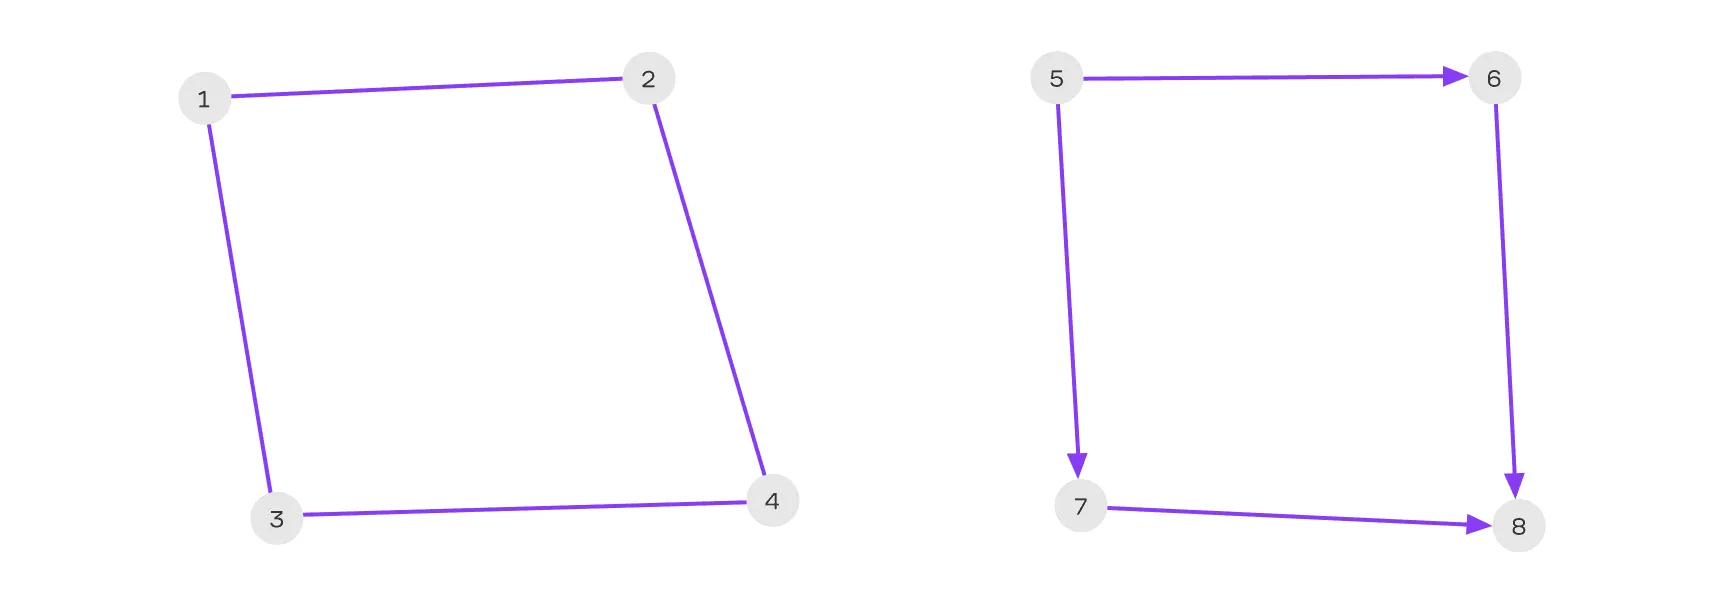

## **4. Классификация №3: по связности**

- **Связный неориентированный граф** — `от любой вершины можно добраться до любой другой по цепочке рёбер`. Все вершины принадлежат одной компоненте связности. Пример: дорожная сеть района, где из каждого посёлка можно доехать до любого другого.  
- **Сильно связный ориентированный граф** — `из любой вершины можно пройти в любую другую, двигаясь строго по направлению рёбер`. Пример: внутренняя система электронной почты, где каждый сотрудник может отправить сообщение любому другому.  
- **Слабо связный ориентированный граф** — `если отбросить направления (считать все рёбра неориентированными), граф становится связным, но с направлениями достижимость из любой в любую не гарантируется`. Пример: граф подписок в соцсетях, где подписка идёт от одного пользователя к другому; в целом все могут быть связаны через цепочки подписок, но не обязательно взаимно.

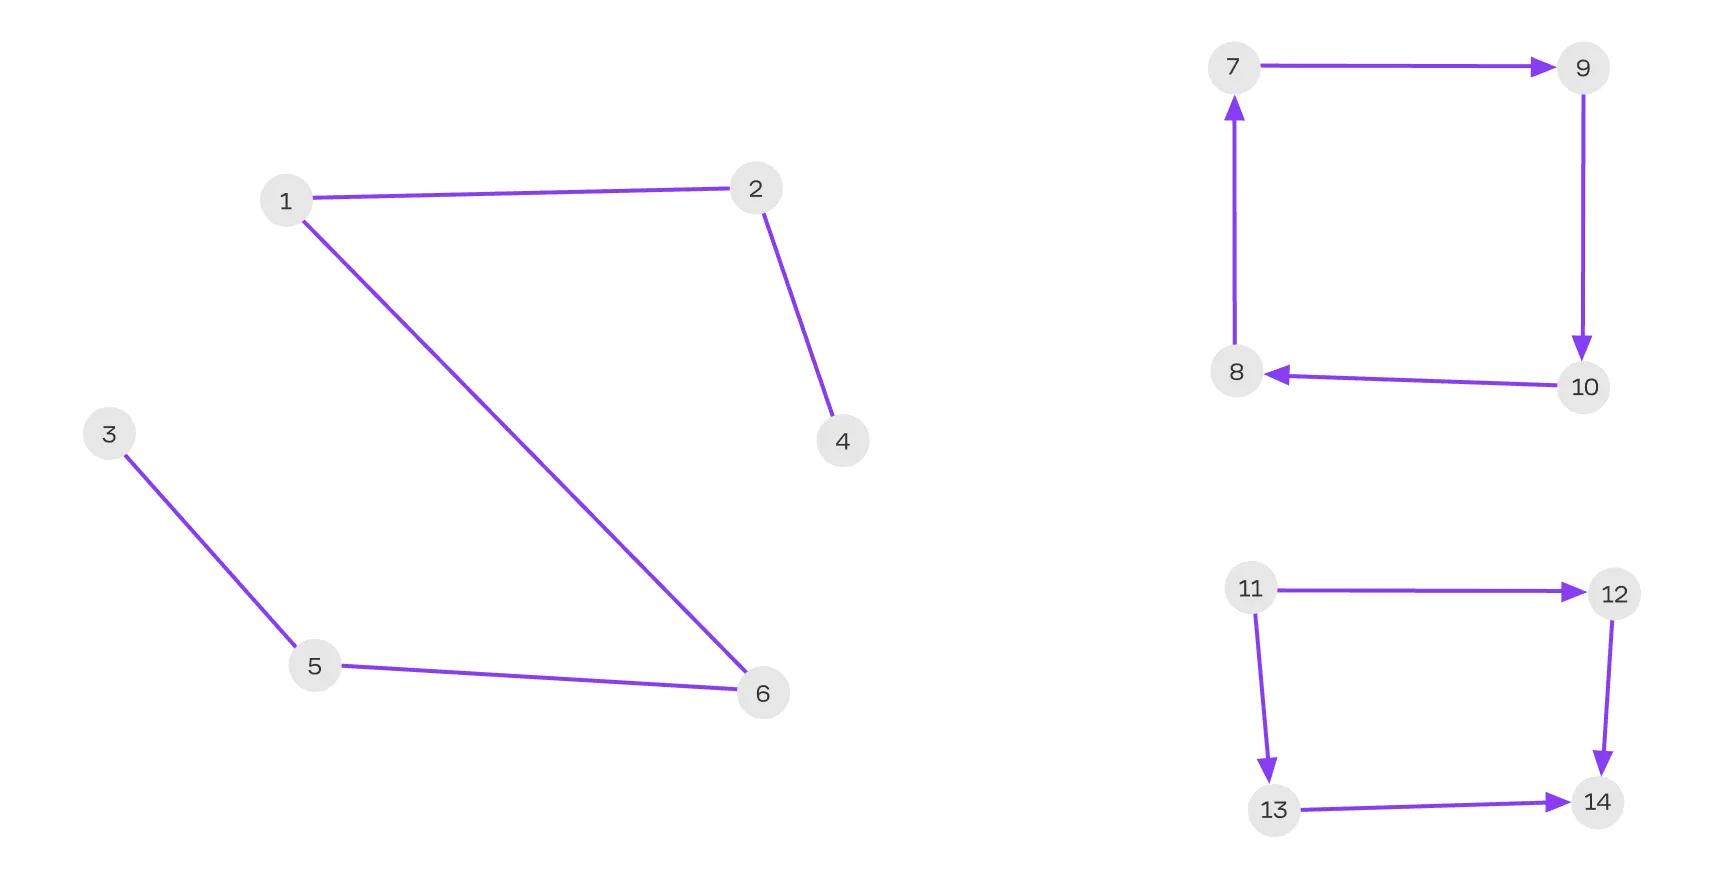


> 1-6 связный неориентированный граф

> 7-10 сильно связный ориентированный граф

> 11-14 слабо связный ориентированный граф



## **5. Классификация №4: по полноте**

- **Полный неориентированный граф** — каждая пара различных вершин соединена ровно одним ребром. Создаёт максимально плотную структуру. Используется, например, для отображения всех попарных расстояний между объектами.  
- **Полный ориентированный граф** — для каждой пары различных вершин есть два ребра: в обе стороны. Позволяет моделировать системы с полным двусторонним взаимодействием всех элементов, например финансовые потоки, где каждый узел может и отправлять, и получать средства от любого другого.

### **Почему существует полный ориентированный граф? Для какой задачи он пригодится**

Кажется, что направления в полном графе не несут смысла — ведь каждая пара вершин и так связана. Однако ценность полного ориентированного графа проявляется, когда дуги имеют **разный вес** или передают **несимметричные отношения**. В отличие от неориентированного графа, где на каждую пару приходится одно ребро, здесь для каждой упорядоченной пары $((A, B)$) хранится отдельная дуга со своим значением, и связь из $(A$) в $(B$) может сильно отличаться от связи из $(B$) в $(A$).

**Примеры:**

- **Финансовые потоки.** Представьте три филиала компании: Москва, Петербург, Казань. Мы хотим видеть все денежные переводы между ними. Дуга из Москвы в Петербург показывает сумму переводов из Москвы в Петербург, а дуга из Петербурга в Москву — обратный поток. Эти суммы почти всегда разные, и только полный ориентированный граф с весами на дугах позволяет точно отразить направления и объёмы движения средств, что важно для анализа баланса и поиска ключевых центров.

- **Спортивный турнир.** Каждая команда играет с каждой по одному разу. Дугу направляют от победителя к проигравшему. В результате получается полный ориентированный граф, который для каждой пары команд показывает, кто кого обыграл. Неориентированный граф просто бы сообщил, что команды встречались, но не сохранил бы результат.


## **6. Лемма о рукопожатиях**

### **Формулировка**

> Это полезный инструмент —  **она позволяет быстро определить общее количество связей в графе по количеству связей каждого элемента**. Зная это, мы можем получить другие данные или проверить правильность нашего графа.




**Формулировка:** сумма степеней всех вершин графа равна удвоенному числу его рёбер.

> $$sum_{v $in V} deg(v) = 2 $cdot |E(G)|$

где

- $deg(v)$ — степень вершины $v$, то есть количество рёбер, соединяющих эту вершину с другими;

- $$sum_{v $in V} deg(v)$ — сумма всех степеней вершин

- 2 $$cdot |E(G)|$ — удвоенное количество ребер

**Объяснение:** каждое ребро имеет два конца и поэтому прибавляет по единице к степени сразу двух вершин. Сложив степени всех вершин, мы каждое ребро учтём ровно два раза.

> Это выражение показывает, что **сумма степеней всех вершин графа всегда является чётным числом**, так как каждое ребро добавляет ровно по единице к степени двух вершин, которые оно соединяет.

### **Пример реализации на Python**

In [ ]:
import networkx as nx
import random

random.seed(42)
graph = nx.erdos_renyi_graph(10, 0.3) # Создаём случайный граф с 10 вершинами и вероятностью ребра 0.3

# Считаем сумму степеней всех вершин
sum_degrees = sum(dict(graph.degree()).values())

# Считаем удвоенное количество рёбер
double_edges = 2 * graph.number_of_edges()

print(f"Сумма степеней: {sum_degrees}") # должно получиться 34
print(f"Удвоенное количество рёбер: {double_edges}") # должно получиться 34

Сумма степеней: 34
Удвоенное количество рёбер: 34


### **Доказательство**

- В пустом графе (0 рёбер) сумма степеней равна 0.  
- При добавлении одного ребра степени двух его концов увеличиваются на 1, общая сумма увеличивается на 2.  
- Значит, после добавления всех рёбер сумма степеней всегда вдвое больше числа рёбер.

### **Следствие**

> **В любом графе число вершин нечётной степени является чётным.**

Это следствие логически вытекает из формулы: так как сумма степеней всех вершин чётна, то и число вершин, имеющих нечётные степени, также должно быть чётным.

### **Небольшое дополнение**


- Для **обыкновенных графов** и **мультиграфов** каждое ребро добавляет по 1 к степеням двух вершин. Сумма степеней$ = (2 $cdot |E|)$.
- Если в графе есть **петля**, она прибавляет к степени вершины **2** (потому что у неё два конца, оба приходят в эту же вершину). Тогда каждое ребро, включая петли, всё равно даёт вклад 2 в общую сумму степеней, и формула сохраняется.
- Для **ориентированного графа** есть похожее правило: сумма всех входящих степеней (in-degree) равна сумме всех исходящих степеней (out-degree) и равна числу дуг.


### **Примеры использования**

| Сфера применения | Вершина | Ребро | Что именно позволяет узнать лемме |
|------------------|---------|-------|-----------------------------------|
| Анализ соцсетей | Пользователь | Дружба/подписка | Проверить целостность данных о связях и вычислить среднее число друзей. |
| Организация соревнований | Участник | Матч между участниками | Проверить корректность распределения матчей между участниками. |
| Проектирование транспортных сетей | Город | Дорога между городами | Убедиться, что учтены все дороги в транспортной системе. |
| Гейм-дизайн | Уровень | Переход между уровнями | Определить, не пропущены ли переходы между уровнями. |
| Грузоперевозки | Склад/логистический центр | Перевозка грузов между объектами | Убедиться, что учтены все перевозки и маршруты. |
| Проектирование бизнес-процессов | Этап задачи | Зависимость между этапами | Убедиться, что все этапы процесса правильно связаны, и нет пропущенных или лишних связей. |

## **7. Двудольные графы**

### **Определение и примеры**

**Определение:** двудольный граф — это граф, вершины которого можно разбить на две непересекающиеся группы (доли) так, что все рёбра идут только между вершинами разных долей. Внутри одной доли рёбер нет.

**Примеры:**  
- Покупатели и товары: ребро означает, что покупатель положил товар в корзину.  
- Студенты и курсы: ребро — запись студента на курс.  

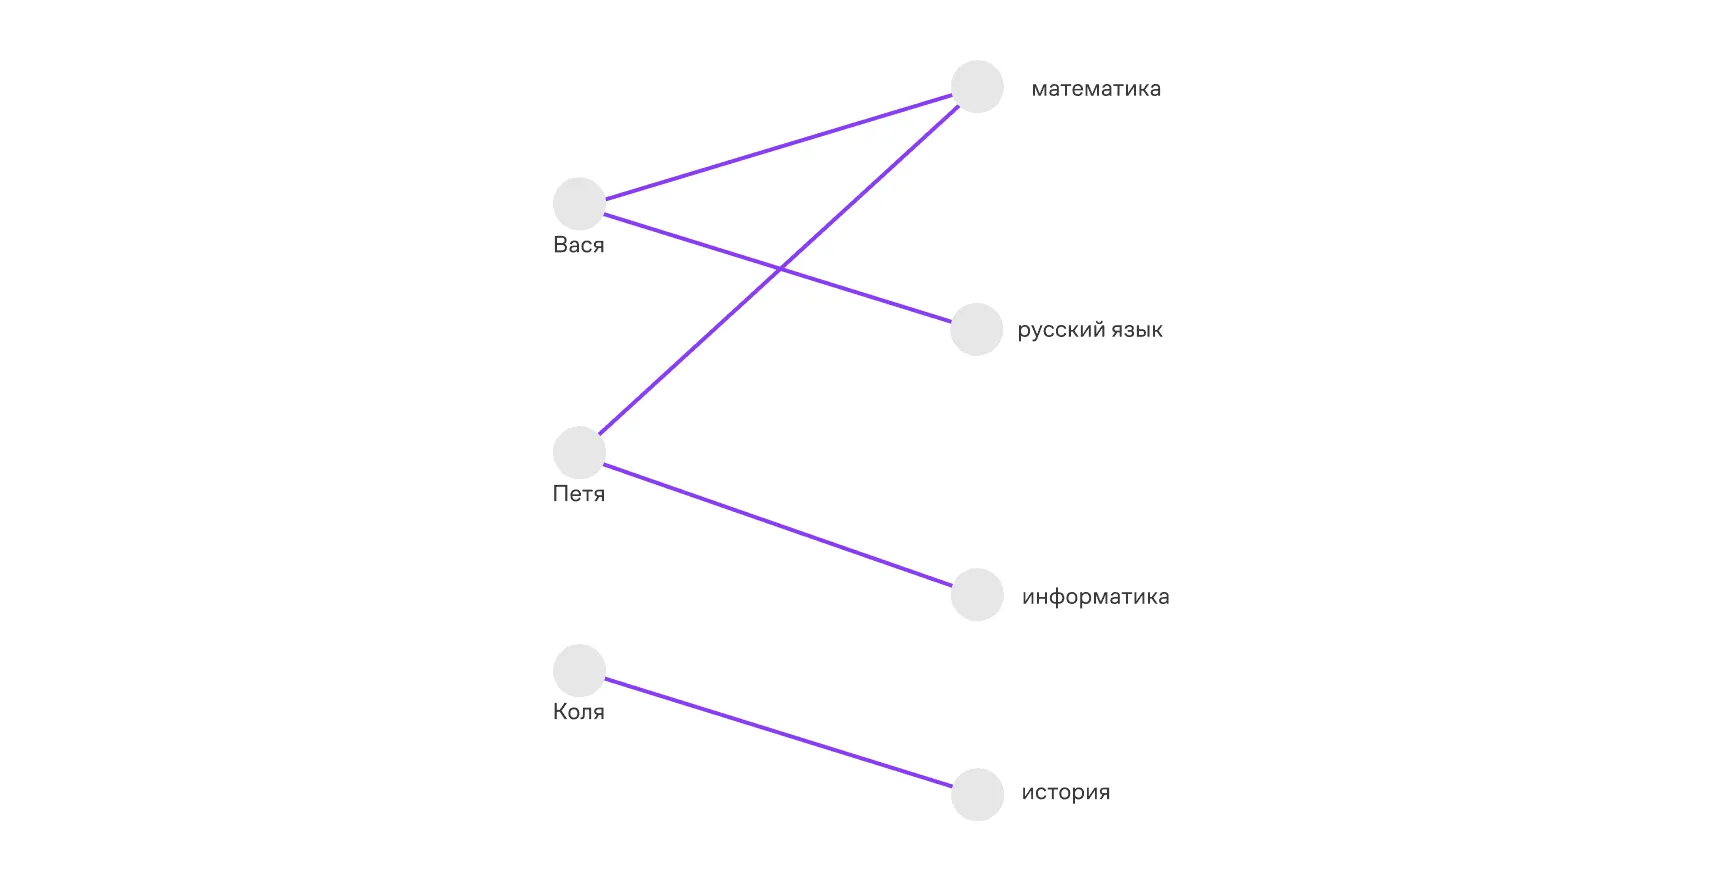

### **Теорема Кёнига**

**Теорема Кёнига:** граф является двудольным тогда и только тогда, когда в нём нет циклов нечётной длины (или циклов вообще).  

#### **Теорему Кёнига можно объяснить следующим образом:**

Если граф двудольный, то в нём действительно не может быть циклов нечётной длины. Представьте, что мы начинаем обход цикла с вершины одной доли и переходим по рёбрам к вершинам другой доли. Чтобы вернуться в начальную вершину, мы должны пройти чётное количество рёбер, и, следовательно, цикл будет чётным.
Если в графе нет циклов нечётной длины, то его можно разделить на две доли. Для доказательства этого можно использовать метод раскраски: раскрасьте вершины графа в два цвета (например, чёрный и белый), так чтобы соседние вершины всегда имели разные цвета. Если в графе нет циклов нечётной длины, такая раскраска будет успешной, и граф можно будет считать двудольным.

### **Строгое доказательство**

#### **Утверждение**

Граф $(G$) является двудольным **тогда и только тогда**, когда все циклы в графе $(G$) имеют чётную длину.


#### **Доказательство**

##### **Необходимое условие**

Пусть граф $(G$) — двудольный. Разделим его вершины на две доли, обозначенные $(U$) и $(V$), где рёбра могут соединять вершины только из разных долей. Если мы начнём обход цикла с некоторой вершины в доле $(U$), то каждый шаг, представляющий ребро, переносит нас из одной доли в другую. Следовательно, чтобы вернуться в начальную вершину, нам нужно пройти чётное количество рёбер, поскольку каждый переход переносит нас в противоположную долю. Таким образом, любой цикл в двудольном графе имеет чётную длину.

##### **Достаточное условие**

Пусть теперь граф $(G$) не содержит циклов нечётной длины. Выберем произвольную вершину $(u$) и определим её как начальную. Разделим все вершины графа на два множества:  
- $(U$) — вершины, находящиеся на **чётном** расстоянии от $(u$);  
- $(V$) — вершины, находящиеся на **нечётном** расстоянии от $(u$)  

(расстояние определяется минимальным числом рёбер). Такое разбиение гарантирует, что $(U $cap V = $varnothing$) и $(U $cup V$) включает все вершины графа.

Теперь допустим, что существует ребро, соединяющее две вершины внутри одной доли, например вершины $(a$) и $(b$) в $(U$). Пусть $(P_a$) — кратчайший путь от $(u$) до $(a$), а $(P_b$) — кратчайший путь от $(u$) до $(b$). Поскольку обе вершины находятся в $(U$), длины путей $(P_a$) и $(P_b$) будут чётными. Если теперь соединить эти пути ребром $(ab$), то получится цикл, длина которого будет равна  
$[
text_{длина}(P_a) + text_{длина}(P_b) + 1,
]$  
то есть чётное + чётное + 1 = нечётное, что противоречит предположению об отсутствии нечётных циклов. Аналогичное рассуждение верно и для вершин в $(V$).

Следовательно, граф $(G$) является двудольным.

#### **Для чего нужно знать двудольные графы?**

**Теорема Кёнига важна для понимания структуры двудольных графов**, так как она позволяет легко проверять двудольность графа с помощью анализа циклов. Это свойство лежит в основе многих алгоритмических приложений. Например:

- Паросочетания в задачах распределения ресурсов. Представьте компанию, которая хочет распределить сотрудников (одна доля графа) на проекты (другая доля графа) так, чтобы максимально учесть предпочтения сотрудников и требования проектов. Двудольный граф здесь позволяет применять алгоритмы нахождения максимального паросочетания, эффективно решая задачу.
- Оптимальное разбиение в логистике. Например, при организации распределительных центров, где точки доставки и склады представляют собой две доли графа. Оптимальное разбиение помогает минимизировать транспортные расходы, создавая сбалансированные маршруты между складами и клиентами.

### **Различные виды двудольных графов**

#### **Полный двудольный**

**Полный двудольный граф $(K_{m,n}$)** — каждая вершина первой доли соединена со всеми вершинами второй доли. Число рёбер равно $(m \times n$), где
m, n — это количество вершин в каждой из долей.. Граф $(K_{1,n}$) называют **звездой**.

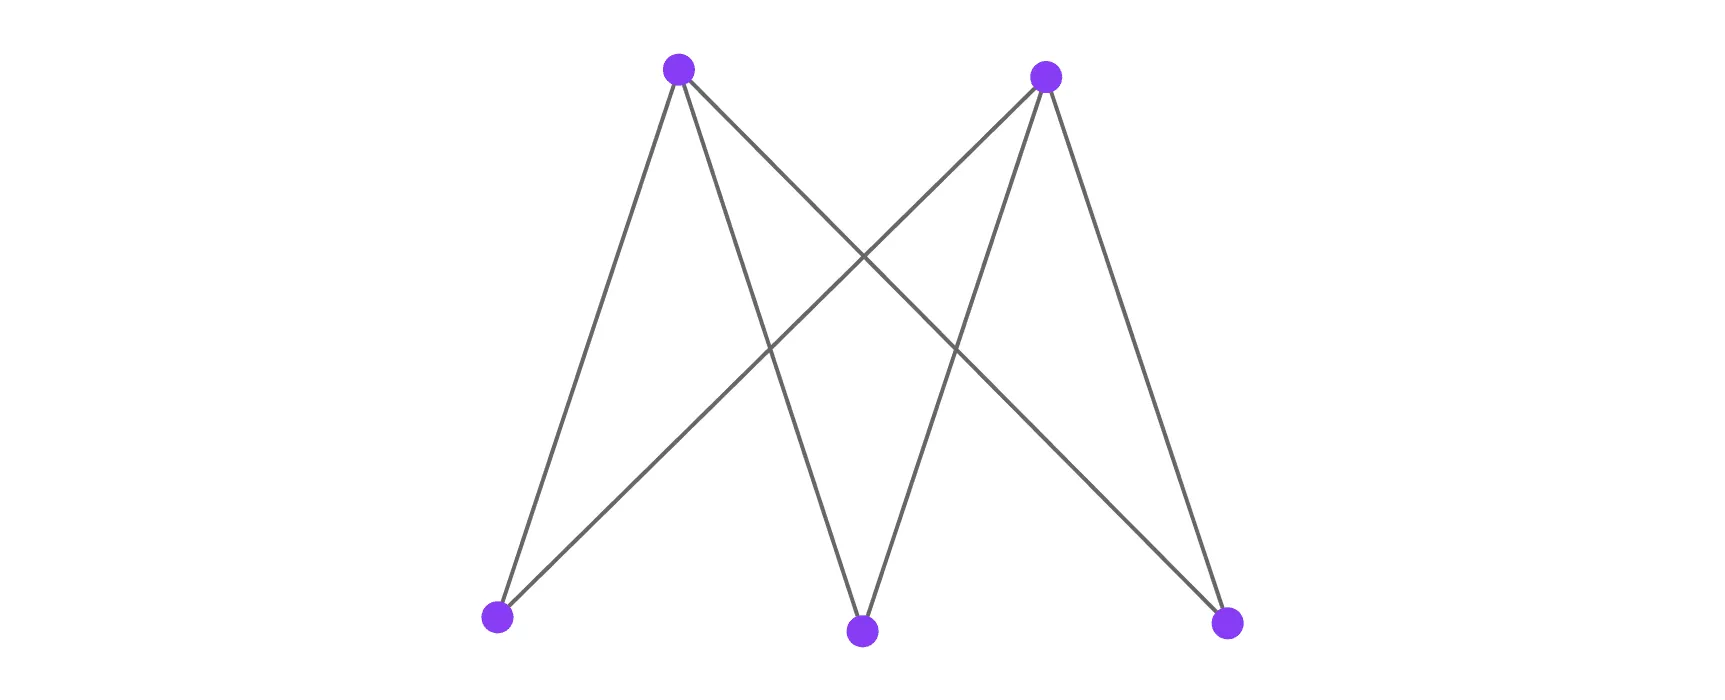

#### **Бинарное дерево**

**Это особый вид двудольного графа, в котором каждая вершина имеет не более двух потомков и не содержит циклов**. В бинарных деревьях существуют понятия:
> корень (вершина, не имеющая предков)

> лист (вершины без потомков)

> узел (все остальные вершины).

Деревья — это важная структура в информатике, особенно в алгоритмах сортировки, поиска и сжатия данных.

Хотя двудольные графы могут быть различными по форме, все деревья, независимо от количества потомков у каждой вершины, тоже считаются двудольными графами.

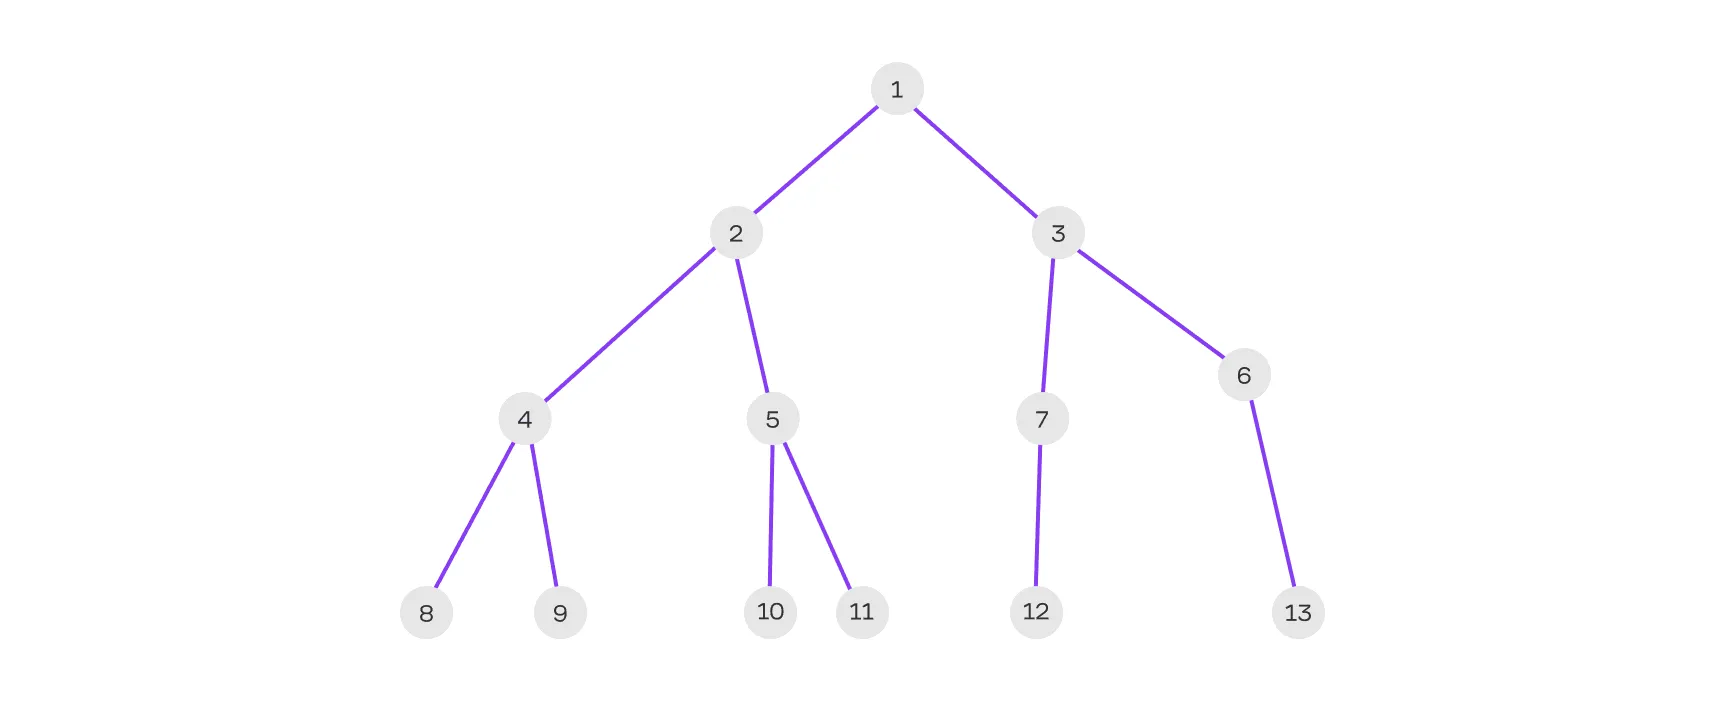